In [ ]:
!pip install tensorflow opencv-python matplotlib tf-explain scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import zipfile

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

!pip install lime
from lime import lime_image
from skimage.segmentation import mark_boundaries
import shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=a808e1120f062abdd2fc06540f4ea634915f21c720532a85f5bf8d7308819012
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import zipfile

zip_path = "archive.zip"  # change if needed, ensure this file is uploaded to your Colab environment

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [ ]:
import os

for root, dirs, files in os.walk("dataset"):
    print(root)

dataset
dataset/data
dataset/data/without_mask
dataset/data/with_mask


In [ ]:
data = []
labels = []

categories = ["with_mask", "without_mask"]
path = "dataset/data"

for category in categories:
    folder_path = os.path.join(path, category)
    label = categories.index(category)

    for img in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img)
        image = cv2.imread(img_path)

        if image is not None:
            image = cv2.resize(image, (100,100))
            data.append(image)
            labels.append(label)

data = np.array(data) / 255.0
labels = np.array(labels)

print("Total images:", len(data))

Total images: 7553


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

In [ ]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(100,100,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(2,activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 103s 534ms/step - accuracy: 0.8491 - loss: 0.3591 - val_accuracy: 0.9173 - val_loss: 0.2235
Epoch 2/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 101s 536ms/step - accuracy: 0.9129 - loss: 0.2205 - val_accuracy: 0.9140 - val_loss: 0.2084
Epoch 3/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 148s 569ms/step - accuracy: 0.9384 - loss: 0.1573 - val_accuracy: 0.9318 - val_loss: 0.1765
Epoch 4/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 103s 542ms/step - accuracy: 0.9556 - loss: 0.1174 - val_accuracy: 0.9332 - val_loss: 0.1914
Epoch 5/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 135s 508ms/step - accuracy: 0.9700 - loss: 0.0827 - val_accuracy: 0.9338 - val_loss: 0.2083


In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 0.9252 - loss: 0.2016
Accuracy: 0.9252150654792786


In [ ]:
model.save("mask_detector_model.h5")

In [ ]:
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt

!wget https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel

--2026-04-01 07:57:04--  https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28104 (27K) [text/plain]
Saving to: ‘deploy.prototxt’

deploy.prototxt     100%[===================>]  27.45K  --.-KB/s    in 0s      

2026-04-01 07:57:05 (122 MB/s) - ‘deploy.prototxt’ saved [28104/28104]

--2026-04-01 07:57:05--  https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/opencv/opencv_3rdparty/dn

In [ ]:
import cv2

prototxt = "deploy.prototxt"
weights = "res10_300x300_ssd_iter_140000.caffemodel"

faceNet = cv2.dnn.readNetFromCaffe(prototxt, weights)

Faces detected: 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


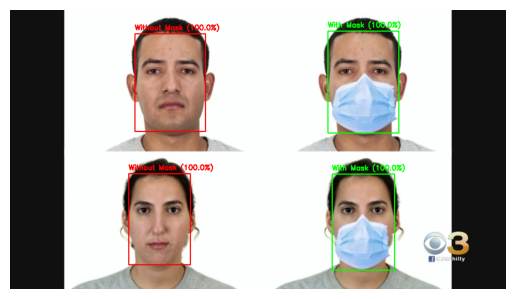

In [ ]:
def detect_faces(image):
    (h, w) = image.shape[:2]
    blob = cv2.dnn.blobFromImage(cv2.resize(image, (300, 300)), 1.0,
                                 (300, 300), (104.0, 177.0, 123.0))
    faceNet.setInput(blob)
    detections = faceNet.forward()

    faces = []
    boxes = []

    for i in range(0, detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > 0.5: # Confidence threshold
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")

            face = image[startY:endY, startX:endX]
            if face.shape[0] > 0 and face.shape[1] > 0: # Ensure face is not empty
                face = cv2.resize(face, (100, 100))
                faces.append(face)
                boxes.append((startX, startY, endX, endY))
    return faces, boxes

img = cv2.imread("mixgrp.jpeg")

if img is None:
    print("Error: Image not found")
else:
    faces, boxes = detect_faces(img)

    print("Faces detected:", len(faces))

    class_names = ["With Mask", "Without Mask"]

    for face, box in zip(faces, boxes):
        (x1,y1,x2,y2) = box

        face_array = face.astype("float32") / 255.0
        face_array = np.reshape(face_array,(1,100,100,3))

        pred = model.predict(face_array)
        cls = np.argmax(pred)
        conf = np.max(pred)*100

        label = class_names[cls]
        color = (0,255,0) if cls==0 else (0,0,255)

        cv2.putText(img,f"{label} ({conf:.1f}%)",(x1,y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX,0.6,color,2)
        cv2.rectangle(img,(x1,y1),(x2,y2),color,2)

    plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
    plt.axis("off")

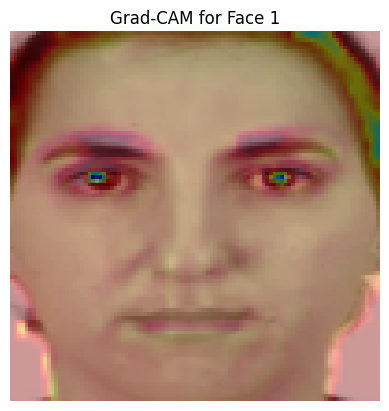

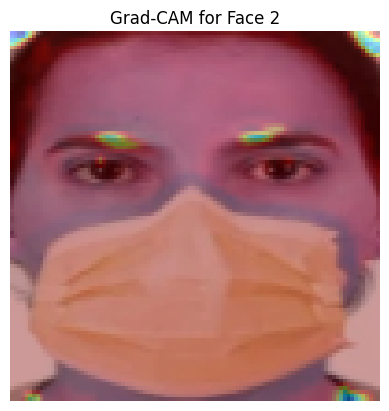

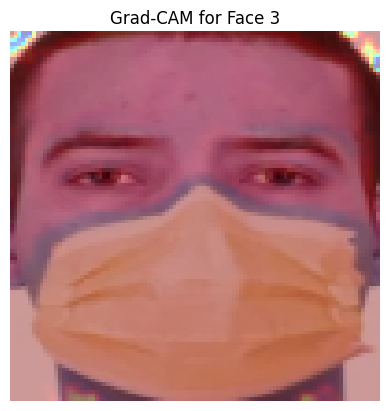

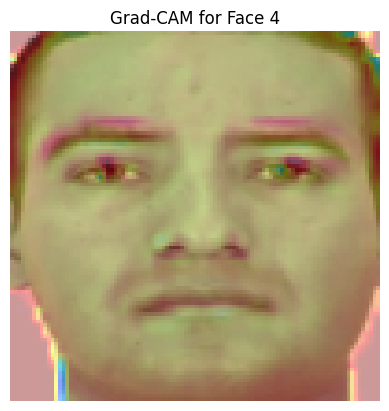

In [ ]:
import tensorflow as tf

if len(faces) == 0:
    print("No faces for Grad-CAM")
else:
    for i, (face, box) in enumerate(zip(faces, boxes)):
        face_array = face.astype("float32") / 255.0
        img_array = np.reshape(face_array,(1,100,100,3))

        img_tensor = tf.convert_to_tensor(img_array)

        last_conv = None
        for layer in reversed(model.layers):
            if "conv" in layer.name:
                last_conv = layer
                break

        conv_model = tf.keras.Model(model.inputs, last_conv.output)

        classifier_input = tf.keras.Input(shape=last_conv.output.shape[1:])
        x = classifier_input

        start=False
        for layer in model.layers:
            if start:
                x = layer(x)
            if layer.name == last_conv.name:
                start=True

        classifier_model = tf.keras.Model(classifier_input, x)

        with tf.GradientTape() as tape:
            conv_out = conv_model(img_tensor)
            tape.watch(conv_out)
            preds = classifier_model(conv_out)
            loss = preds[:, np.argmax(preds[0])]

        grads = tape.gradient(loss, conv_out)
        pooled = tf.reduce_mean(grads, axis=(0,1,2))

        conv_out = conv_out[0]
        heatmap = conv_out @ pooled[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)

        heatmap = tf.maximum(heatmap,0)/tf.reduce_max(heatmap)
        heatmap = heatmap.numpy()

        heatmap = cv2.resize(heatmap,(100,100))
        heatmap = np.uint8(255*heatmap)

        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

        face_uint8 = (face_array*255).astype("uint8")
        overlay = cv2.addWeighted(face_uint8,0.6,heatmap,0.4,0)

        plt.figure()
        plt.imshow(overlay)
        plt.title(f"Grad-CAM for Face {i+1}")
        plt.axis("off")
    plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━

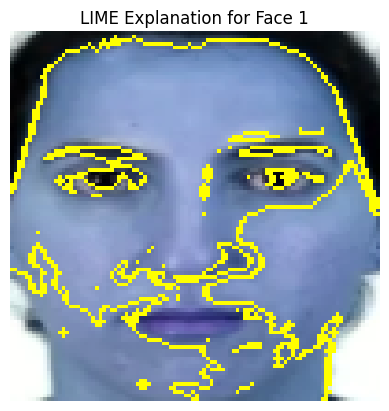

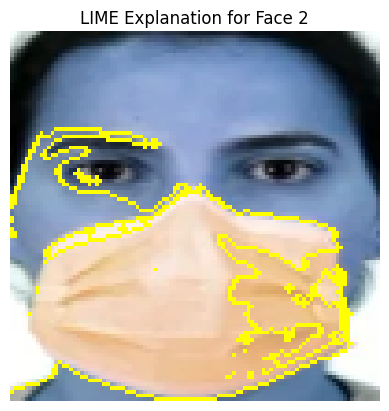

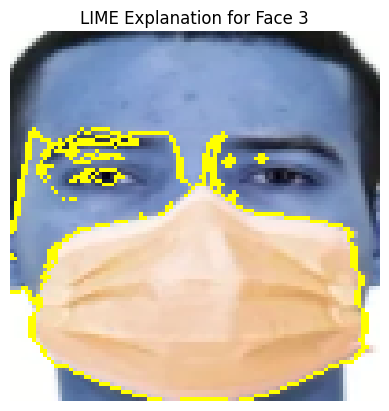

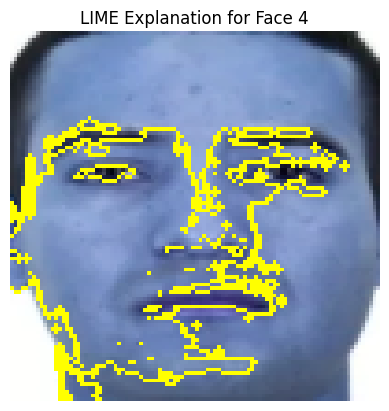

In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

if len(faces) == 0:
    print("No faces for LIME")
else:
    def predict_fn(images):
        images = np.array(images)
        images = np.array([cv2.resize(img,(100,100)) for img in images])
        images = images.astype("float32")/255.0
        return model.predict(images)

    explainer = lime_image.LimeImageExplainer()

    for i, face in enumerate(faces):
        explanation = explainer.explain_instance(
            face.astype('double'),
            predict_fn,
            top_labels=2,
            hide_color=0,
            num_samples=1000
        )

        temp,mask = explanation.get_image_and_mask(
            explanation.top_labels[0],
            positive_only=True,
            num_features=5,
            hide_rest=False
        )

        plt.figure()
        plt.imshow(mark_boundaries(temp/255.0,mask))
        plt.title(f"LIME Explanation for Face {i+1}")
        plt.axis("off")
    plt.show()

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(30, 100, 100, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(60, 100, 100, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1, 100, 100, 3

<Figure size 600x600 with 0 Axes>

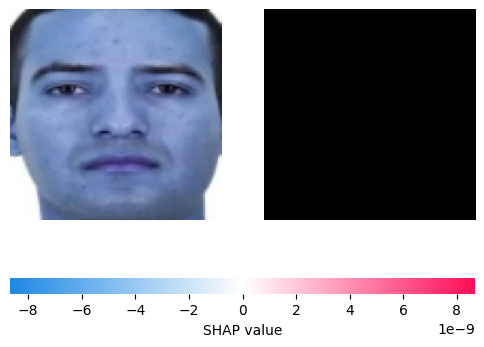

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Select background images from training data
background_size = 30
background = X_train[np.random.choice(X_train.shape[0], background_size, replace=False)]

# Step 2: Create SHAP explainer
explainer = shap.DeepExplainer(model, background)

# Step 3: Generate SHAP values for the test image
shap_values = explainer.shap_values(img_array)

# Step 4: Display SHAP explanation
plt.figure(figsize=(6,6))
shap.image_plot(shap_values, img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


<Figure size 600x600 with 0 Axes>

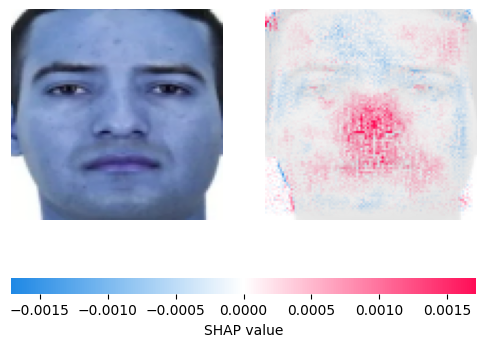

In [ ]:
predicted_class = np.argmax(model.predict(img_array))

plt.figure(figsize=(6,6))
shap.image_plot([shap_values[:, :, :, :, predicted_class]], img_array)